# Time Series Analysis Demo Notebook

This notebook is designed for classroom demonstration alongside the slide deck.

Topics covered:
- White noise vs random walk
- Stationarity and non-stationarity
- Unit roots and the Augmented Dickey–Fuller test
- ACF and PACF
- AR(1) behaviour for different values of \(\phi\)
- Forecasting and evaluation with ARIMA

**Teaching tip:** pause after each plot and ask students to interpret it before moving on.

## 1. Setup
We use:
- `numpy` and `pandas` for data handling
- `matplotlib` for plotting
- `statsmodels` for ACF/PACF, ADF, and ARIMA
- `sklearn` for evaluation metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(7)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## 2. White noise vs random walk

A **white noise** series has:
- constant mean
- constant variance
- no autocorrelation

A **random walk** accumulates shocks over time, so it is usually non-stationary in levels.

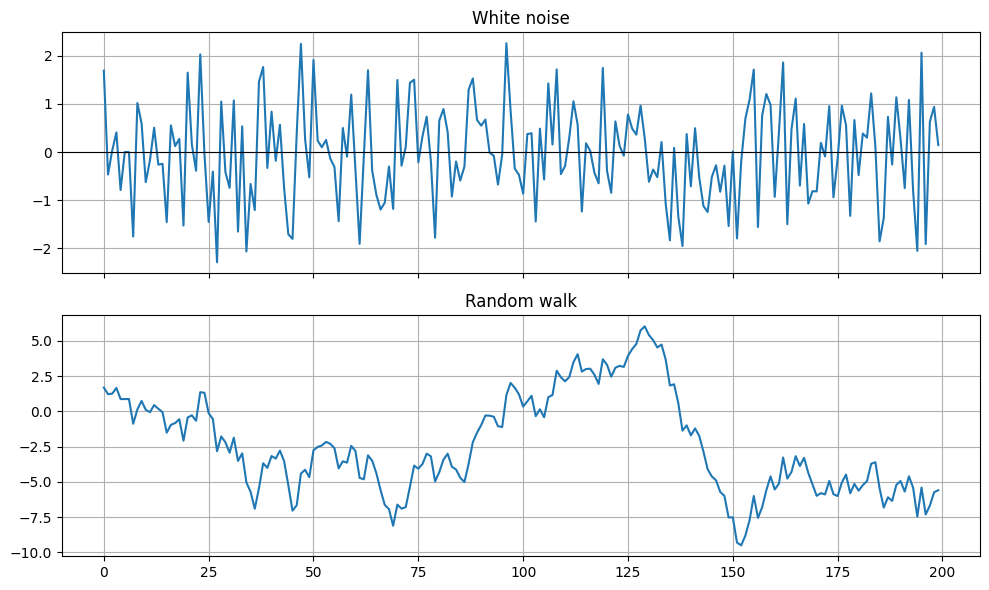

In [2]:
n = 200
eps = np.random.normal(size=n)
random_walk = np.cumsum(eps)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(eps)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("White noise")

axes[1].plot(random_walk)
axes[1].set_title("Random walk")

plt.tight_layout()
plt.show()

### Quick discussion prompt
- Which series would be easier to model with a stable rule?
- Which one looks like shocks keep accumulating?

## 3. Stationary vs non-stationary synthetic examples

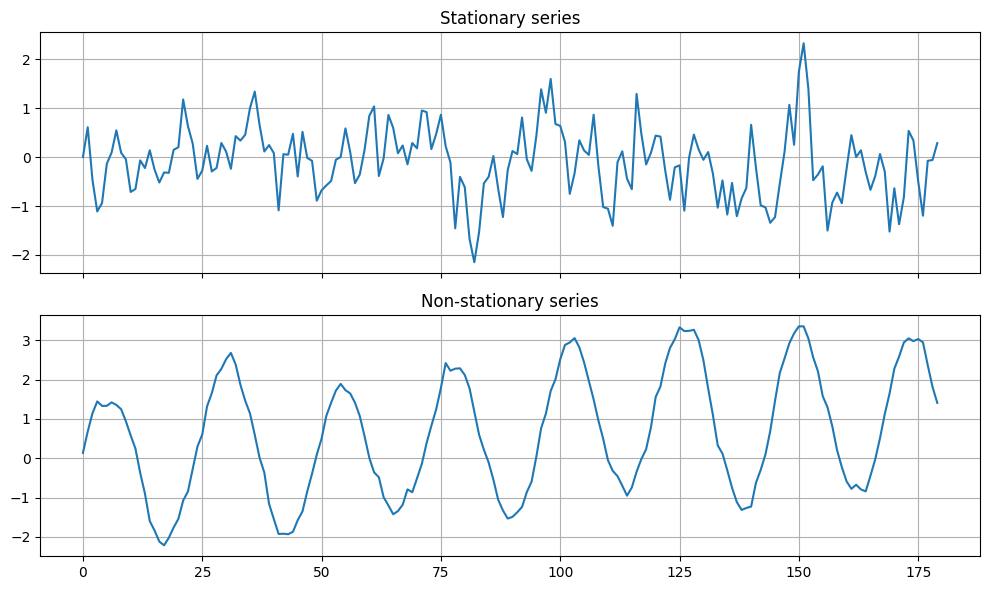

In [3]:
# stationary AR(1)-like process
e = np.random.normal(scale=0.6, size=180)
stationary = np.zeros(180)
for t in range(1, 180):
    stationary[t] = 0.65 * stationary[t-1] + e[t]

# non-stationary process with trend + seasonality + accumulated noise
t = np.arange(180)
nonstationary = 0.03*t + 2*np.sin(2*np.pi*t/24) + np.cumsum(np.random.normal(scale=0.15, size=180))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(stationary)
axes[0].set_title("Stationary series")

axes[1].plot(nonstationary)
axes[1].set_title("Non-stationary series")

plt.tight_layout()
plt.show()

## 4. Augmented Dickey–Fuller (ADF) test

Interpretation reminder:
- **Null hypothesis**: the series has a unit root (non-stationary)
- **Alternative hypothesis**: the series is stationary

A small p-value suggests evidence against the null.

In [4]:
def adf_summary(series, name="series"):
    result = adfuller(series, autolag="AIC")
    print(f"ADF test for {name}")
    print("-" * 40)
    print(f"Test statistic : {result[0]:.4f}")
    print(f"p-value        : {result[1]:.4f}")
    print(f"Lags used      : {result[2]}")
    print(f"Observations   : {result[3]}")
    print("Critical values:")
    for k, v in result[4].items():
        print(f"  {k}: {v:.4f}")
    print()

adf_summary(stationary, "stationary synthetic series")
adf_summary(nonstationary, "non-stationary synthetic series")

ADF test for stationary synthetic series
----------------------------------------
Test statistic : -6.9094
p-value        : 0.0000
Lags used      : 0
Observations   : 179
Critical values:
  1%: -3.4674
  5%: -2.8778
  10%: -2.5755

ADF test for non-stationary synthetic series
----------------------------------------
Test statistic : -1.6372
p-value        : 0.4637
Lags used      : 13
Observations   : 166
Critical values:
  1%: -3.4704
  5%: -2.8791
  10%: -2.5761



### Teaching note
Students should see that the stationary series typically gives stronger evidence against a unit root than the non-stationary series.

## 5. Differencing to remove a unit root
For many non-stationary series, the **first difference** is much more stable than the original level series.

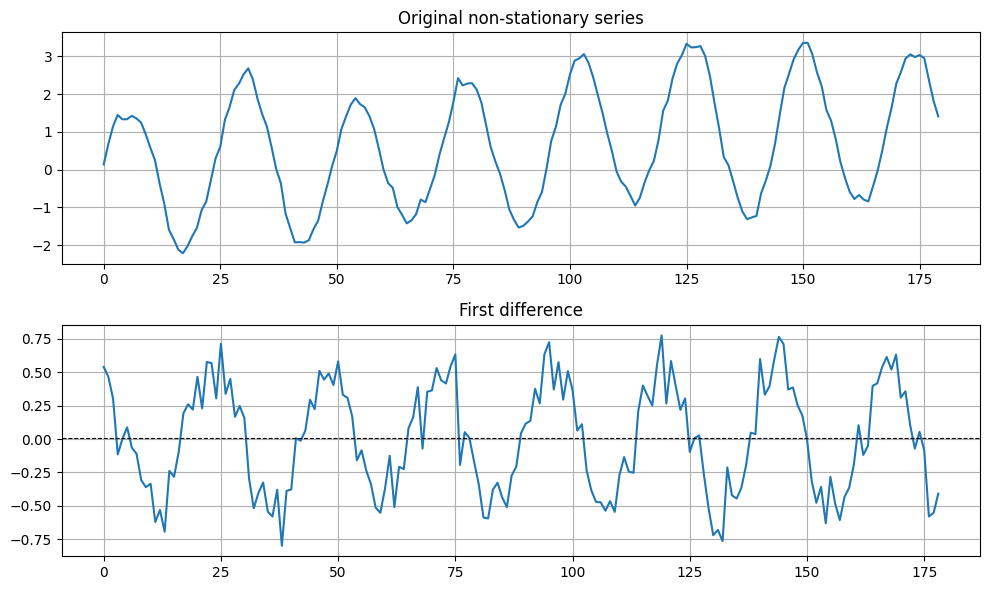

ADF test for first-differenced series
----------------------------------------
Test statistic : -8.2514
p-value        : 0.0000
Lags used      : 14
Observations   : 164
Critical values:
  1%: -3.4709
  5%: -2.8793
  10%: -2.5763



In [6]:
diff_nonstationary = np.diff(nonstationary)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
axes[0].plot(nonstationary)
axes[0].set_title("Original non-stationary series")

axes[1].plot(diff_nonstationary)
axes[1].axhline(np.mean(diff_nonstationary), color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("First difference")

plt.tight_layout()
plt.show()

adf_summary(diff_nonstationary, "first-differenced series")

## 6. ACF and PACF for an AR(1) process

Rule of thumb:
- **AR(p)**: ACF tails off, PACF cuts off after lag \(p\)
- **MA(q)**: ACF cuts off after lag \(q\), PACF tails off

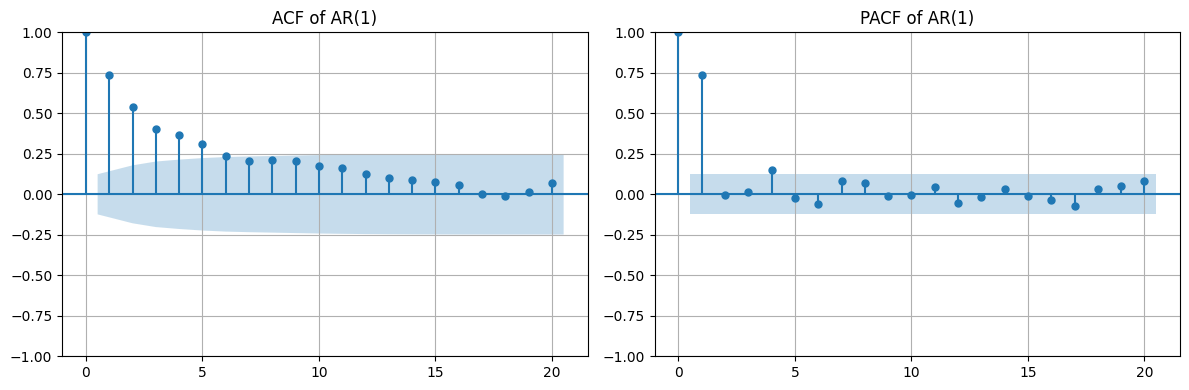

In [7]:
phi = 0.75
ar1_process = ArmaProcess(np.array([1, -phi]), np.array([1]))
ar1 = ar1_process.generate_sample(250)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ar1, lags=20, ax=axes[0])
axes[0].set_title("ACF of AR(1)")

plot_pacf(ar1, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of AR(1)")

plt.tight_layout()
plt.show()

## 7. ACF and PACF for an MA(1) process
Now compare that pattern with an MA(1) series.

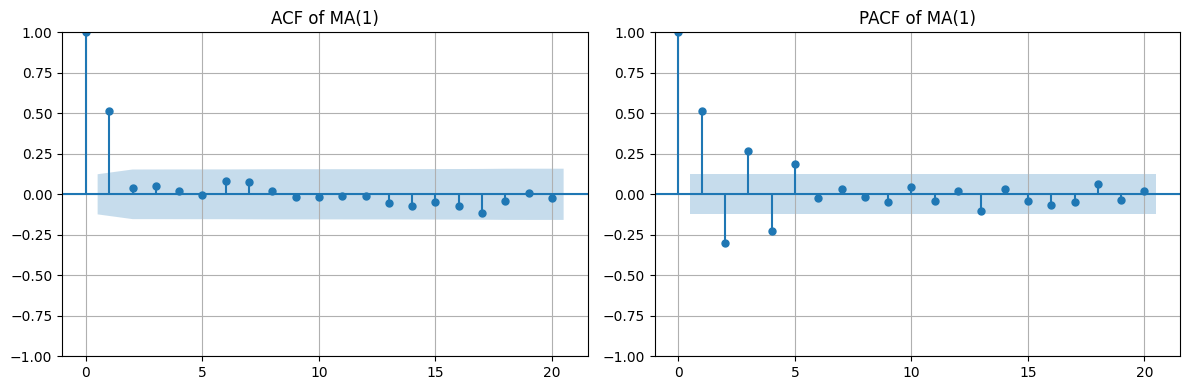

In [8]:
theta = 0.7
ma1_process = ArmaProcess(np.array([1]), np.array([1, theta]))
ma1 = ma1_process.generate_sample(250)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ma1, lags=20, ax=axes[0])
axes[0].set_title("ACF of MA(1)")

plot_pacf(ma1, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of MA(1)")

plt.tight_layout()
plt.show()

## 8. AR(1) behaviour for different values of \(\phi\)

Interpretation:
- small positive \(\phi\): weak persistence
- large positive \(\phi\): strong persistence
- negative \(\phi\): oscillation / reversal

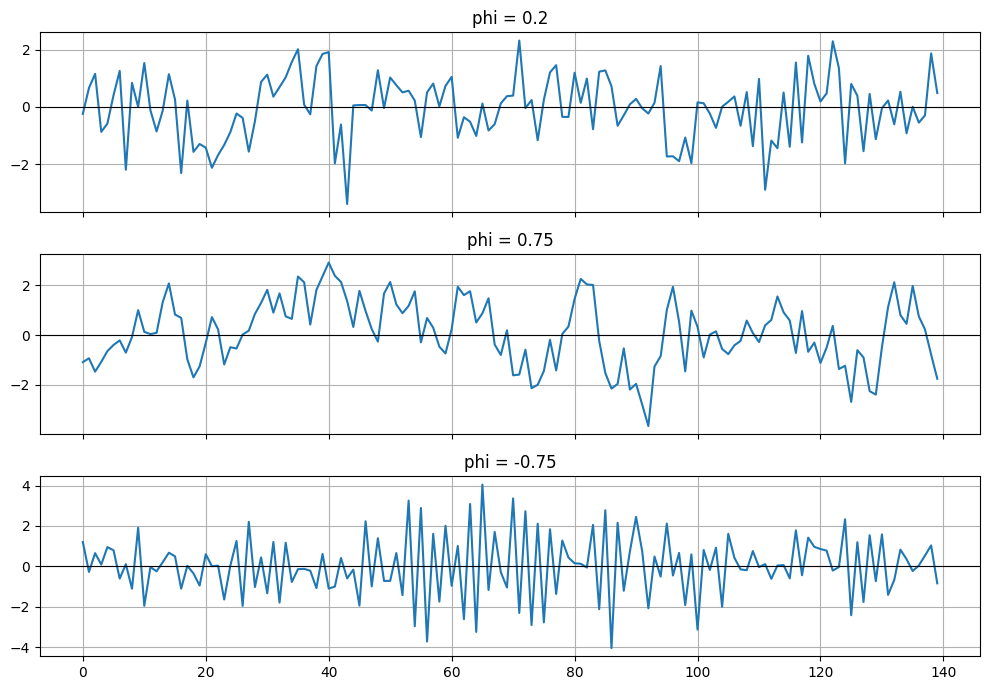

In [9]:
phis = [0.2, 0.75, -0.75]
labels = ["phi = 0.2", "phi = 0.75", "phi = -0.75"]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for ax, phi, label in zip(axes, phis, labels):
    process = ArmaProcess(np.array([1, -phi]), np.array([1]))
    x = process.generate_sample(140)
    ax.plot(x)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(label)

plt.tight_layout()
plt.show()

## 9. Seasonal data and forecasting example

We create a simple series with:
- trend
- seasonality
- noise

Then we:
1. split into train and test
2. fit a seasonal ARIMA model
3. forecast
4. evaluate using MAE and RMSE

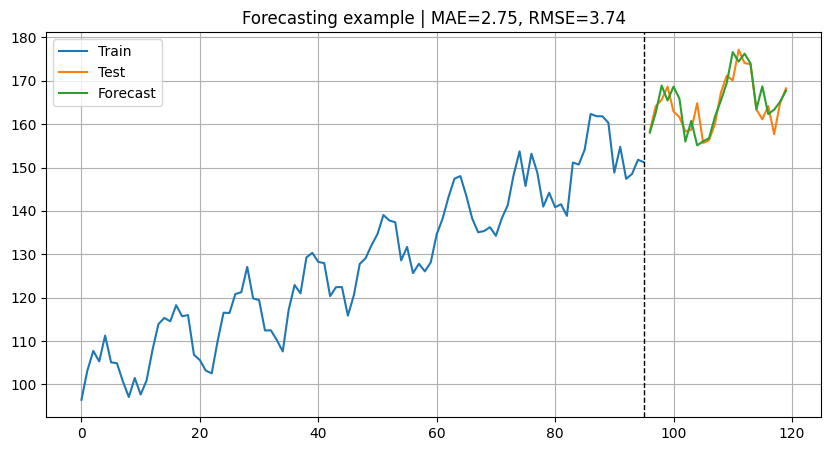

MAE : 2.747
RMSE: 3.741


In [10]:
n = 120
t = np.arange(n)
series = 100 + 0.6*t + 8*np.sin(2*np.pi*t/12) + np.random.normal(scale=2.5, size=n)

train = series[:96]
test = series[96:]

model = ARIMA(train, order=(2, 1, 1), seasonal_order=(1, 1, 0, 12))
result = model.fit()
forecast = result.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast)
rmse = mean_squared_error(test, forecast) ** 0.5

plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(train)), train, label="Train")
plt.plot(np.arange(len(train), len(series)), test, label="Test")
plt.plot(np.arange(len(train), len(series)), forecast, label="Forecast")
plt.axvline(len(train)-1, color="black", linestyle="--", linewidth=1)
plt.title(f"Forecasting example | MAE={mae:.2f}, RMSE={rmse:.2f}")
plt.legend()
plt.show()

print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))

## 10. Why random train-test split is wrong in time series

In ordinary machine learning, random splitting is often acceptable.

In time series, it is usually **wrong** because:
- it mixes past and future
- it leaks future information into training
- it gives overly optimistic estimates of accuracy

Always preserve chronology.

## 11. Suggested in-class exercises

1. Generate an AR(1) series with three different values of \(\phi\) and compare plots.  
2. Difference a random walk and run the ADF test before and after differencing.  
3. Simulate an MA(1) series and compare its ACF/PACF with an AR(1) series.  
4. Change the seasonal period in the forecasting example and see what happens.  
5. Try a different forecast horizon and compare MAE vs RMSE.

## 12. One-line summary for students

**Time series analysis is about extracting stable temporal structure from ordered data so that explanation and forecasting become possible.**